# Copertura scraper TALIA — mappa comuni siciliani

Colora ogni comune della Sicilia in base alla piattaforma di scraping attiva
per l'albo pretorio, usando il registro in `scripts/run_scrapers.py` e i
confini comunali pubblici (OpenPolis/ISTAT, `data/comuni_sicilia_confini.geojson`).

Dipendenze extra (non nel `pyproject.toml` di TALIA, solo per questo notebook):
`pip install matplotlib shapely nbformat`


In [1]:
import json
import sys
import importlib.util

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

REPO_ROOT = "/Users/dom/Documents/GitHub/talia"  # adattare se il repo è altrove
GEOJSON_PATH = f"{REPO_ROOT}/data/comuni_sicilia_confini.geojson"

spec = importlib.util.spec_from_file_location("run_scrapers", f"{REPO_ROOT}/scripts/run_scrapers.py")
rs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rs)


## Mappatura codice ISTAT → famiglia di piattaforma

Legge i registri `_JCITYGOV_COMUNI`, `_PORTALEPA_COMUNI`, `_HALLEY_COMUNI` di
`run_scrapers.py` e i 5 scraper dedicati (Palermo, Catania, Trapani, Siracusa,
Agrigento). Se un comune è coperto da più fonti (es. jCityGov + Halley),
vince la prima assegnata — non cambia la logica di scraping, solo il colore
sulla mappa.

In [2]:
_DEDICATI = {
    "082053": "dedicato",  # Palermo
    "087015": "dedicato",  # Catania
    "081021": "dedicato",  # Trapani
    "089017": "dedicato",  # Siracusa
    "084001": "dedicato",  # Agrigento (Playwright)
}

_COLORI = {
    "jcitygov": "#2b8a3e",
    "portalepa": "#1c7ed6",
    "halley": "#e8590c",
    "dedicato": "#9c36b5",
    "nessuno": "#e9ecef",
}

_LABEL = {
    "jcitygov": "jCityGov",
    "portalepa": "portalepa",
    "halley": "Halley EG",
    "dedicato": "Scraper dedicato",
    "nessuno": "Non coperto",
}


def famiglia_per_comune() -> dict[str, str]:
    fam: dict[str, str] = {}
    for entry in rs._JCITYGOV_COMUNI:
        fam[entry[2]] = "jcitygov"
    for entry in rs._PORTALEPA_COMUNI:
        fam.setdefault(entry[2], "portalepa")
    for entry in rs._HALLEY_COMUNI:
        fam.setdefault(entry[2], "halley")
    for codice in _DEDICATI:
        fam[codice] = "dedicato"
    return fam


fam_map = famiglia_per_comune()
print(f"{len(fam_map)} comuni con scraper attivo su {391} totali")


174 comuni con scraper attivo su 391 totali


## Disegno della mappa

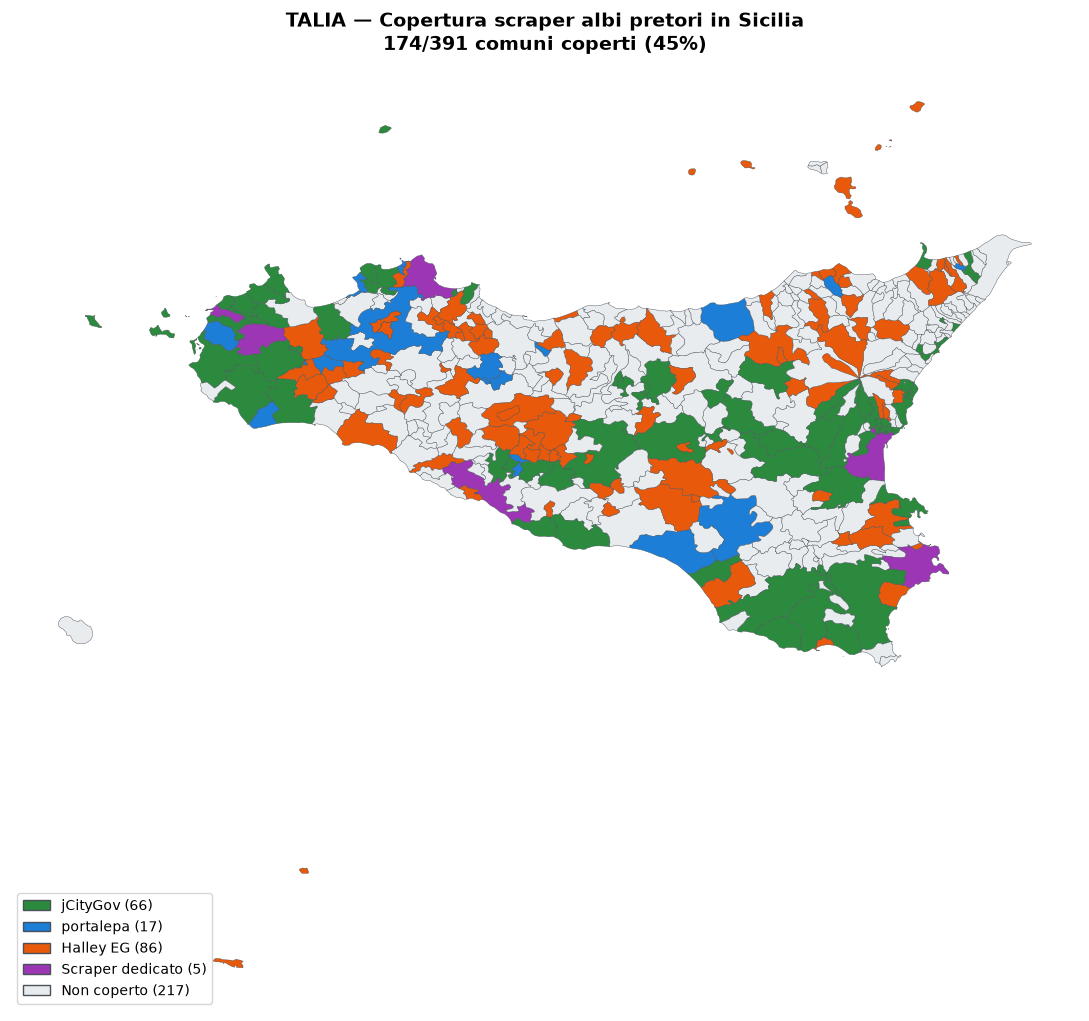

{'jcitygov': 66, 'portalepa': 17, 'halley': 86, 'dedicato': 5, 'nessuno': 217}


In [3]:
def disegna_geometria(ax, geometry, facecolor):
    gtype = geometry["type"]
    if gtype == "Polygon":
        rings = [geometry["coordinates"][0]]
    elif gtype == "MultiPolygon":
        rings = [poly[0] for poly in geometry["coordinates"]]
    else:
        return
    for ring in rings:
        patch = MplPolygon(ring, closed=True)
        ax.add_patch(patch)
        patch.set_facecolor(facecolor)
        patch.set_edgecolor("#495057")
        patch.set_linewidth(0.3)


with open(GEOJSON_PATH) as f:
    geo = json.load(f)

fig, ax = plt.subplots(figsize=(11, 11))
conteggio = {k: 0 for k in _COLORI}

for feature in geo["features"]:
    codice = feature["properties"]["com_istat_code"]
    famiglia = fam_map.get(codice, "nessuno")
    conteggio[famiglia] += 1
    disegna_geometria(ax, feature["geometry"], _COLORI[famiglia])

ax.set_aspect("equal")
ax.autoscale_view()
ax.axis("off")

tot = sum(conteggio.values())
coperti = tot - conteggio["nessuno"]
ax.set_title(
    f"TALIA — Copertura scraper albi pretori in Sicilia\n"
    f"{coperti}/{tot} comuni coperti ({coperti/tot:.0%})",
    fontsize=14, fontweight="bold",
)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=_COLORI[k], edgecolor="#495057")
    for k in ["jcitygov", "portalepa", "halley", "dedicato", "nessuno"]
]
legend_labels = [f"{_LABEL[k]} ({conteggio[k]})" for k in ["jcitygov", "portalepa", "halley", "dedicato", "nessuno"]]
ax.legend(legend_handles, legend_labels, loc="lower left", fontsize=10, frameon=True)

plt.tight_layout()
plt.savefig("mappa_copertura_sicilia.png", dpi=150, bbox_inches="tight")
plt.show()

print(conteggio)


## Nota sulle due metriche di copertura

- **% comuni** (questa mappa): 174/391 ≈ 45% — pesa Aliminusa (1.291 ab.) come Palermo.
- **% popolazione** (usata in `docs/wiki/14-censimento-albi.md`): ≈ 69,9% — pesa per abitanti,
  più rilevante per l'impatto civico reale dello strumento.

## TIER 2 Comuni (Custom/Proprietari) — Analisi 2026-07-10**Oggetto:** 5 comuni con piattaforme non-standard (EG0, WordPress custom, OpenPA, ecc.).Analisi di fattibilità per scraper HTTP puro:| Comune | Pop. | Piattaforma | Complessità | ROI | Raccomandazione ||--------|------|-------------|-------------|-----|-----------------|| San Giuseppe Jato | 8.5k | EG0 (proprietario) | ALTO | BASSO | ❌ Scartato || Petrosino | 7.7k | WordPress + API JS | MEDIO-ALTO | MEDIO | ⏸ Futuro (Playwright) || Pantelleria | 7.5k | OpenPA/Drupal | MEDIO | MEDIO | ⏸ Futuro (se OpenPA generico) || Marineo | 6.7k | WordPress + MC (form) | MEDIO | BASSO | ❌ Bassa priorità || Balestrate | 6.4k | WordPress + API JS | MEDIO-ALTO | BASSO | ❌ Bassa priorità |**Conclusione:** Nessuno dei 5 comuni è facilmente scrapabile con HTTP puro. Priorità rimane Palermo + Catania (E2) e consolidamento jCityGov (E3, 60+ comuni).Documento completo: `docs/wiki/14-tier2-reverse-engineering-comuni-2026-07.md`